# PVGIS-only ST-GNN + SDE-Net (drift/diffusion) pipeline

Reproducible orchestrator for the final run on server **newzealand**.

Does **not** duplicate runner/analysis logic — it builds commands and reads the
CSVs they write, via `physiq_pv.experiments.sde_pipeline`.

Safety switches: `RUN_TRAINING`, `RUN_ANALYSIS`, `LOG_TO_WANDB`.

The selected experiment uses the paper regression likelihood: Gaussian NLL with beta=0. Run the notebook from the config cell onward; the results section reads only that run's output directory.

## 1. Setup

In [1]:
import os, sys, subprocess
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
os.environ['PYTHONPATH'] = str(REPO_ROOT) + os.pathsep + os.environ.get('PYTHONPATH', '')
os.chdir(REPO_ROOT)

from physiq_pv.experiments import sde_pipeline as pipe
print('repo root:', REPO_ROOT)

repo root: /home/apedalino/physiq_pv


In [2]:
PVGIS_DIR = pipe.PVGIS_DIR
TEST_ANOMALY_SCORES = pipe.TEST_ANOMALY_SCORES
TRAIN_ANOMALY_SCORES = pipe.TRAIN_ANOMALY_SCORES
ANALYSIS_SCRIPT = pipe.ANALYSIS_SCRIPT

checks = {
    'PVGIS dir': Path(PVGIS_DIR).is_dir(),
    'test anomaly scores': Path(TEST_ANOMALY_SCORES).exists(),
    'train anomaly scores': Path(TRAIN_ANOMALY_SCORES).exists(),
    'analysis script': Path(ANALYSIS_SCRIPT).exists(),
}
try:
    import physiq_pv.experiments.pvgis_stgnn_runner  # noqa: F401
    checks['runner importable'] = True
except Exception as e:
    checks['runner importable'] = False
    print('runner import error:', e)
for k, v in checks.items():
    print(('OK     ' if v else 'MISSING') + '  ' + k)

OK       PVGIS dir
OK       test anomaly scores
MISSING  train anomaly scores
OK       analysis script
OK       runner importable


If the anomaly scores are **missing**, regenerate them (run in a terminal — not launched automatically):

In [3]:
if not (Path(TEST_ANOMALY_SCORES).exists() and Path(TRAIN_ANOMALY_SCORES).exists()):
    base = ('PYTHONPATH=$PWD python scripts/run_pvgis_climatology_anomaly_years.py'
            ' --pvgis-dir ' + PVGIS_DIR +
            ' --climatology-start-year 2005 --climatology-end-year 2018'
            ' --rolling-past-climatology'
            ' --quantile 0.975 --climatology-window-days 15 --min-climatology-years 3'
            ' --variables solar_irradiance_poa pv_power_output temperature_2m wind_speed_10m'
            ' --out-root outputs')
    print('# Test year 2019:')
    print(base + ' --years 2019')
    print()
    print('# Train years 2016-2018 (aggregated):')
    print(base + ' --years 2016,2017,2018 --aggregate-out-dir ' + str(Path(TRAIN_ANOMALY_SCORES).parent))
else:
    print('anomaly scores present.')

# Test year 2019:
PYTHONPATH=$PWD python scripts/run_pvgis_climatology_anomaly_years.py --pvgis-dir /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance --climatology-start-year 2005 --climatology-end-year 2018 --rolling-past-climatology --quantile 0.975 --climatology-window-days 15 --min-climatology-years 3 --variables solar_irradiance_poa pv_power_output temperature_2m wind_speed_10m --out-root outputs --years 2019

# Train years 2016-2018 (aggregated):
PYTHONPATH=$PWD python scripts/run_pvgis_climatology_anomaly_years.py --pvgis-dir /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance --climatology-start-year 2005 --climatology-end-year 2018 --rolling-past-climatology --quantile 0.975 --climatology-window-days 15 --min-climatology-years 3 --variables solar_irradiance_poa pv_power_output temperature_2m wind_speed_10m --out-root outputs --years 2016,2017,2018 --aggregate-out-dir outputs/pvgis_anomaly_train_2016_2018_2005_past_w15_q0975


## 2. Single-run config

In [4]:
# === EXPERIMENT SELECTOR ===
# One paper-faithful SDE-Net regression run, retaining the project's ST-GNN
# backbone, auxiliary irradiance objective, data and features.
EXPERIMENT = 'paper_faithful_gaussian'
BASE_CONFIG = {**pipe.DEFAULT_CONFIG,
    'name': 'paper_faithful_gaussian_ep60',
    'epochs': 60, 'batch_size': 16, 'lr': 1e-4, 'lr_g': 1e-2,
    'dropout': 0.0, 'train_normal_only': False,
    'n_sde_steps': 4, 'sigma_max': 0.5,
    'sde_sigma_initial': 0.01, 'sde_sigma_warmup_epochs': 30,
    'ood_noise_std': 2.0, 'mc_samples': 10, 'seed': 1,
    'ood_smoke_test': True, 'ood_smoke_max_samples': 2048,
}

out_dir = pipe.make_out_dir(BASE_CONFIG)
run_name = pipe.make_run_name(BASE_CONFIG)
print('experiment:', EXPERIMENT)
print('config    :', BASE_CONFIG)
print('out_dir   :', out_dir)
print('run_name  :', run_name)
if Path(out_dir).exists():
    print('WARNING: out_dir already exists — a run would overwrite its files.')

experiment: paper_faithful_gaussian
config    : {'train_years': '2016,2017,2018', 'test_year': 2019, 'seq_len': 24, 'horizon': 1, 'target_variable': 'pv_power_output', 'model_type': 'stgnn', 'feature_set': 'full', 'epochs': 60, 'batch_size': 16, 'lr': 0.0001, 'lr_g': 0.01, 'dropout': 0.0, 'mc_samples': 10, 'seed': 1, 'n_sde_steps': 4, 'sigma_max': 0.5, 'sde_sigma_initial': 0.01, 'sde_sigma_warmup_epochs': 30, 'ood_noise_std': 2.0, 'ood_smoke_test': True, 'ood_smoke_max_samples': 2048, 'gradient_clip_norm': 100.0, 'lr_decay_epoch': 20, 'lr_decay_factor': 0.1, 'irradiance_loss_weight': 0.1, 'pv_target_clip_max': 'none', 'name': 'paper_faithful_gaussian_ep60', 'train_normal_only': False}
out_dir   : outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1
run_name  : pvgis_stgnn_paper_faithful_gaussian_ep60_seed1


## 3. Training command

In [5]:
train_cmd = pipe.build_train_command(
    BASE_CONFIG, out_dir=out_dir, run_name=run_name,
    pvgis_dir=PVGIS_DIR, test_anomaly_scores=TEST_ANOMALY_SCORES,
    train_anomaly_scores=TRAIN_ANOMALY_SCORES, device='cuda', use_wandb=True)
# Keep W&B run logging enabled, but do not upload runner artifacts.
assert '--wandb' in train_cmd
assert '--no-wandb-upload-artifacts' in train_cmd
print(' \\\n  '.join(train_cmd))

/home/apedalino/physiq_pv/.venv/bin/python \
  -m \
  physiq_pv.experiments.pvgis_stgnn_runner \
  --pvgis-dir \
  /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance \
  --anomaly-scores \
  outputs/pvgis_anomaly_2019_2005_2018_w15_q0975/pvgis_climatology_scores.csv \
  --train-years \
  2016,2017,2018 \
  --test-year \
  2019 \
  --seq-len \
  24 \
  --horizon \
  1 \
  --target-variable \
  pv_power_output \
  --model-type \
  stgnn \
  --feature-set \
  full \
  --irradiance-loss-weight \
  0.1 \
  --epochs \
  60 \
  --batch-size \
  16 \
  --lr \
  0.0001 \
  --lr-g \
  0.01 \
  --dropout \
  0.0 \
  --mc-samples \
  10 \
  --pv-target-clip-max \
  none \
  --seed \
  1 \
  --n-sde-steps \
  4 \
  --sigma-max \
  0.5 \
  --sde-sigma-initial \
  0.01 \
  --sde-sigma-warmup-epochs \
  30 \
  --ood-noise-std \
  2.0 \
  --ood-smoke-max-samples \
  2048 \
  --gradient-clip-norm \
  100.0 \
  --lr-decay-epoch \
  20 \
  --lr-decay-factor \
  0.1 \
  --use-irradiance-head \
  --us

## 4. Run training

Set `RUN_TRAINING = True` to actually launch.

In [6]:
RUN_TRAINING = True

if RUN_TRAINING:
    subprocess.run(train_cmd, check=True)
else:
    print('RUN_TRAINING is False — not launching. Command above is what would run.')

INFO: paper-style protocol — two-source uncertainty (Kong et al. 2020): epistemic = Var of the SDE Brownian-path predictive means, aleatoric = mean of the Gaussian PV head variance. The primary interval (lower_pi/upper_pi) uses equal-tail quantiles of the Gaussian mixture across paths; the moment-matched Gaussian band is retained as a diagnostic. 


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/apedalino/.netrc.
wandb: Currently logged in as: albertopedalino (albertopedalino-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /home/apedalino/physiq_pv/wandb/run-20260724_122310-ddh9h9m9
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pvgis_stgnn_paper_faithful_gaussian_ep60_seed1
wandb: ⭐️ View project at https://wandb.ai/albertopedalino-politecnico-di-torino/physiq_pv
wandb: 🚀 View run at https://wandb.ai/albertopedalino-politecnico-di-torino/physiq_pv/runs/ddh9h9m9


[wandb] run id=ddh9h9m9 name=pvgis_stgnn_paper_faithful_gaussian_ep60_seed1 -> out_dir=outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1
[wandb] run metadata -> outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1/wandb_run.json
[config] seed=1  batch_size=16  epochs=60  mc_samples=10  ood_smoke_test=True  skip_predictions_csv=False  train_years=2016,2017,2018  test_year=2019  pv_target_clip_max=None  n_sde_steps=4  sigma_max=0.5  sde_sigma_initial=0.01  sde_sigma_warmup_epochs=30  ood_noise_std=2.0  lr_g=0.01  gradient_clip_norm=100.0  lr_decay_epoch=20  lr_decay_factor=0.1  use_irradiance_head=True  use_irradiance_loss=True  irradiance_loss_weight=0.1  out_dir=outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1
[1/6] Loading PVGIS years (train=[2016, 2017, 2018], test=2019) | model=stgnn feature_set=full n_features=11
  [ok]   loaded PVGIS year 2016: piedmont_pvgis_2016.nc
  [ok]   loaded PVGIS year 2017: piedmont_pvgis_2017.nc
  [ok]   loaded PVGIS year 2018: piedmont_pvgi

wandb: uploading console lines 88-92; updating run metadata
wandb: uploading console lines 88-92
wandb: uploading data
wandb: uploading history steps 60-60, summary, console lines 93-722
wandb: 
wandb: Run history:
wandb:              clc_gaussian/daytime ▁
wandb: clc_gaussian/extreme_peak_daytime ▁
wandb:               clc_gaussian/global ▁
wandb:         clc_gaussian/high_daytime ▁
wandb:            clc_gaussian/nighttime ▁
wandb:               clc_gaussian/normal ▁
wandb:       clc_gaussian/normal_daytime ▁
wandb:     clc_gaussian/normal_nighttime ▁
wandb:         clc_gaussian/peak_daytime ▁
wandb:         clc_gaussian/rare_extreme ▁
wandb:                              +612 ...
wandb: 
wandb: Run summary:
wandb:                        best_epoch 59
wandb:            best_validation_metric rmse_daytime
wandb:             best_validation_score 71.25406
wandb:              clc_gaussian/daytime 0.49585
wandb: clc_gaussian/extreme_peak_daytime 0.45755
wandb:               clc_gaussian/gl

## 5. Post-hoc analysis

In [7]:
RUN_ANALYSIS = True

analysis_cmd = pipe.build_analysis_command(out_dir, BASE_CONFIG)
print(' \\\n  '.join(analysis_cmd))
if RUN_ANALYSIS:
    subprocess.run(analysis_cmd, check=True)
else:
    print('RUN_ANALYSIS is False — not launching.')

/home/apedalino/physiq_pv/.venv/bin/python \
  scripts/analyze_pvgis_daytime_report.py \
  --predictions \
  outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1/predictions.csv \
  --out-dir \
  outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1 \
  --epochs \
  60 \
  --dropout \
  0.0 \
  --mc-samples \
  10
[load] scanned 10,037,664 rows; 4,747,545 daytime candidates (solar > 10.0 W/m^2); kept 4,747,545 valid, skipped 0 invalid; 5,290,119 nighttime
[sharpness] target_range = 891.8600 (y_true_min 1.4100, y_true_max 893.2700)
[done] wrote:
  outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1/daytime_bin_anomaly_report.md
  outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1/daytime_anomaly_overview.csv
  outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1/daytime_bin_summary.csv
  outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1/daytime_bin_anomaly_metrics.csv
  outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1/frequency_weighted_bin_summary.csv
  outputs/p

## 6. Results & figures

Reads the CSVs the runner/analysis wrote, then shows: summary tables, the
SDE band (predictive std) by anomaly group, and the post-hoc figures
(per-sample MAE/NMPIL boxplots + pooled PICP/CLC bar charts, one figure per
production-percentage bin, split by anomaly category). The ST-GNN SDE head
reports epistemic and aleatoric components separately.

In [8]:
def _read(name):
    p = Path(out_dir) / name
    return pd.read_csv(p) if p.exists() else None

RESULT_FILES = ['metrics_global.csv','metrics_daytime.csv','metrics_by_anomaly_label.csv',
                'residual_bias_and_bin_metrics.csv','daytime_bin_summary.csv',
                'daytime_bin_anomaly_metrics.csv','frequency_weighted_bin_summary.csv',
                'uncertainty_response.csv','sharpness_overview.csv']
results = {n: _read(n) for n in RESULT_FILES}
for n, df in results.items():
    print((('OK  ' if df is not None else '--  ') + n) + (('  ' + str(df.shape)) if df is not None else ''))

OK  metrics_global.csv  (1, 9)
OK  metrics_daytime.csv  (12, 26)
OK  metrics_by_anomaly_label.csv  (6, 9)
OK  residual_bias_and_bin_metrics.csv  (19, 24)
OK  daytime_bin_summary.csv  (5, 9)
OK  daytime_bin_anomaly_metrics.csv  (30, 13)
OK  frequency_weighted_bin_summary.csv  (6, 14)
OK  uncertainty_response.csv  (5, 8)
OK  sharpness_overview.csv  (7, 11)


In [9]:
sharp = results['sharpness_overview.csv']
if sharp is not None:
    cols = [c for c in ['scope','count','picp','mae','rmse','mean_std','mpiw','nmpil'] if c in sharp.columns]
    display(sharp[cols])
bins = results['daytime_bin_summary.csv']
if bins is not None:
    display(bins)
freq = results['frequency_weighted_bin_summary.csv']
if freq is not None:
    display(freq)
unc = results['uncertainty_response.csv']
if unc is not None:
    display(unc)

,scope,count,picp,mae,rmse,mean_std,mpiw,nmpil
0,overall_daytime,4747545,0.953109,42.795314,69.611211,57.287057,224.561523,0.251790
1,normal,4156850,0.955395,41.642161,67.554261,57.088466,223.783089,0.250917
2,rare_extreme,590695,0.937020,50.910305,82.651187,58.684584,230.039531,0.257932
3,unusually_low_solar_potential,96867,0.869553,99.085280,130.571700,75.424688,295.659445,0.331509
4,unusually_high_solar_potential,39289,0.969686,48.689826,76.247620,58.094018,227.724473,0.255337
5,extreme_temperature_condition,273209,0.957889,35.807803,62.272904,51.946660,203.627279,0.228318
6,extreme_wind_condition,228107,0.936065,52.144161,80.892670,63.399678,248.522470,0.278656


,bin,count,mae,rmse,picp,mean_std,mpiw,nmpil,production_peak_nmpil
0,daytime_0_20_pct,1934608,39.747960,67.899050,0.939790,42.639861,167.145918,0.187413,0.234444
1,daytime_20_40_pct,856630,46.085206,69.215440,0.946897,65.499345,256.752889,0.287885,0.360130
2,daytime_40_60_pct,736468,46.909133,70.018292,0.959568,71.553850,280.486035,0.314496,0.393419
3,daytime_60_80_pct,669745,44.625367,74.478547,0.966422,69.824803,273.708358,0.306896,0.383912
4,daytime_80_100_pct,550094,40.653592,69.493255,0.984768,61.645512,241.646125,0.270946,0.338940


,category,count,frequency_of_daytime,frequency_weighted_picp,frequency_weighted_mae,frequency_weighted_rmse,frequency_weighted_abs_picp_gap,frequency_weighted_undercoverage_gap,frequency_weighted_overcoverage_gap,dominant_bin,dominant_bin_frequency,max_gap_bin,max_gap_bin_frequency,max_abs_picp_gap
0,normal,4156850,0.875579,0.955395,41.642161,67.554261,0.010518,0.002562,0.007957,daytime_0_20_pct,0.400619,daytime_80_100_pct,0.109689,0.035192
1,rare_extreme,590695,0.124421,0.937020,50.910305,82.651187,0.026844,0.019912,0.006932,daytime_0_20_pct,0.455897,daytime_0_20_pct,0.455897,0.041312
2,unusually_low_solar_potential,96867,0.020404,0.869553,99.085280,130.571700,0.080489,0.080468,0.000021,daytime_0_20_pct,0.998751,daytime_0_20_pct,0.998751,0.080569
3,unusually_high_solar_potential,39289,0.008276,0.969686,48.689826,76.247620,0.026658,0.003486,0.023172,daytime_80_100_pct,0.722060,daytime_20_40_pct,0.034793,0.044879
4,extreme_temperature_condition,273209,0.057547,0.957889,35.807803,62.272904,0.019872,0.005991,0.013881,daytime_0_20_pct,0.358857,daytime_80_100_pct,0.172685,0.042115
5,extreme_wind_condition,228107,0.048047,0.936065,52.144161,80.892670,0.018782,0.016359,0.002424,daytime_0_20_pct,0.434178,daytime_20_40_pct,0.170635,0.028771


,category,mae_ratio_vs_normal,rmse_ratio_vs_normal,std_ratio_vs_normal,picp_delta_vs_normal,mpiw_ratio_vs_normal,nmpil_ratio_vs_normal,underdispersion_flag
0,rare_extreme,1.222566,1.223479,1.027959,-0.018375,1.027958,1.027958,True
1,unusually_low_solar_potential,2.379446,1.932842,1.321190,-0.085842,1.321188,1.321188,True
2,unusually_high_solar_potential,1.169244,1.128687,1.017614,0.014291,1.017613,1.017613,True
3,extreme_temperature_condition,0.859893,0.921821,0.909933,0.002494,0.909931,0.909931,False
4,extreme_wind_condition,1.252196,1.197447,1.110551,-0.019330,1.110551,1.110551,True


In [10]:
# SDE total predictive std by anomaly group. Seasonal anomaly labels are
# evaluation strata only.
_pred = Path(out_dir) / 'predictions.csv'
if _pred.exists():
    _df = pd.read_csv(_pred, usecols=['anomaly_group', 'solar_irradiance_poa_target',
                                      'y_pred_std'])
    _day = _df[_df['solar_irradiance_poa_target'] > 10.0]
    display(_day.groupby('anomaly_group')[['y_pred_std']].mean())
else:
    print('predictions.csv not found — run training first.')

,y_pred_std
anomaly_group,
normal,57.088466
rare_or_extreme,58.684584


In [11]:
import pandas as pd
# Epistemic vs aleatoric on the CURRENTLY SELECTED experiment (run cell 2 first).
# Does NOT reassign out_dir and uses a private _ea frame so it can't shadow the
# reliability cell's `df` guard.
_ea = pd.read_csv(str(Path(out_dir) / 'predictions.csv'),
                  usecols=['epistemic_std', 'aleatoric_std', 'solar_irradiance_poa_target'])
_ea_day = _ea[_ea['solar_irradiance_poa_target'] > 10]
print('out_dir:', out_dir)
print(_ea_day[['epistemic_std', 'aleatoric_std']].mean())
print('epistemic / aleatoric ratio:',
      (_ea_day['epistemic_std'].mean() / _ea_day['aleatoric_std'].mean()).round(4))

out_dir: outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1
epistemic_std     0.027365
aleatoric_std    57.286276
dtype: float64
epistemic / aleatoric ratio: 0.0005


reading: outputs/pvgis_stgnn_paper_faithful_gaussian_ep60_seed1/predictions.csv
dist=gaussian  target_range=891.86  RMSE=69.61  gaussian_z=1.960  (gamma=0.95, eta=9.0)
                             model   PICP   MPIW  NMPIL  MPIW_RMSE    CLC
                  model (saved PI) 0.9531 224.56 0.2518      3.226 0.4966
model (Gaussian moment diagnostic) 0.9531 224.56 0.2518      3.226 0.4966

Controlled pseudo-OOD smoke test (not real held-out OOD):
             score  n_id  n_ood  id_mean    ood_mean  ood_to_id_ratio  auroc  aupr_out  aupr_in  tnr_at_tpr95  detection_accuracy
epistemic_variance  2048   2048 0.005597 3412.749495    609799.194770    1.0       1.0      1.0           1.0                 1.0
         diffusion  2048   2048 0.000266    0.999774      3752.453996    1.0       1.0      1.0           1.0                 1.0


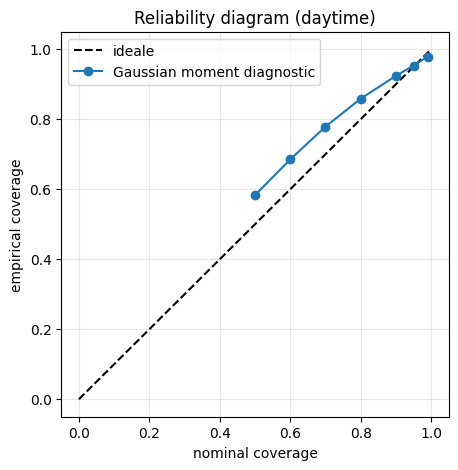

 nominal  empirical
    0.50     0.5832
    0.60     0.6851
    0.70     0.7788
    0.80     0.8586
    0.90     0.9240
    0.95     0.9531
    0.99     0.9792


In [12]:
import numpy as np, pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# Predictions of the CURRENTLY SELECTED experiment — derive out_dir from
# BASE_CONFIG so a stale global out_dir can't point at the wrong run.
out_dir = pipe.make_out_dir(BASE_CONFIG)
PRED_CSV = str(Path(out_dir) / "predictions.csv")
print("reading:", PRED_CSV)
GAMMA, ETA = 0.95, 9.0
SOLAR_COL, SOLAR_THR = "solar_irradiance_poa_target", 10.0

# Primary intervals are exact quantiles of the sampled Gaussian mixture.
# A moment-matched Gaussian band is retained only as a diagnostic.
NLL_DIST = 'gaussian'
z = float(norm.ppf(0.5 + GAMMA / 2))

want = ["y_true", "y_pred_mean", "y_pred_std_raw", "lower_pi", "upper_pi",
        SOLAR_COL, "timestamp", "location"]
# Always load from the selected run's CSV (no stale in-memory df shortcut).
d = pd.read_csv(PRED_CSV, usecols=lambda c: c in want)

# --- daytime + finite ---
d = d[d[SOLAR_COL] > SOLAR_THR]
need = ["y_true", "y_pred_mean", "y_pred_std_raw"]
d = d[np.isfinite(d[need].to_numpy()).all(axis=1)].reset_index(drop=True)

y = d["y_true"].to_numpy(float)
mu = d["y_pred_mean"].to_numpy(float)
sig = d["y_pred_std_raw"].to_numpy(float)

rng = y.max() - y.min()                       # target_range (come report)
rmse = np.sqrt(np.mean((mu - y) ** 2))

clc = lambda picp, nmpil: nmpil * (1.0 + np.exp(-ETA * (picp - GAMMA)))  # = report CLC

def metrics(lo, hi, name):
    inside = (y >= lo) & (y <= hi)
    picp, mpiw = inside.mean(), np.mean(hi - lo)
    nmpil = mpiw / rng
    return dict(model=name, PICP=round(picp, 4), MPIW=round(mpiw, 2),
                NMPIL=round(nmpil, 4), MPIW_RMSE=round(mpiw / rmse, 3),
                CLC=round(clc(picp, nmpil), 4))

rows = []
# 1) modello, PI Gaussian-mixture primari salvati dal runner
rows.append(metrics(d["lower_pi"].to_numpy(float), d["upper_pi"].to_numpy(float), "model (saved PI)"))
# 2) diagnostica moment-matched Gaussian sulla varianza totale
rows.append(metrics(mu - z * sig, mu + z * sig, "model (Gaussian moment diagnostic)"))
# No test-fitted homoscedastic/climatology baselines: fitting them on y_test
# would leak evaluation targets and they are not part of this primary run.

res = pd.DataFrame(rows)[["model", "PICP", "MPIW", "NMPIL", "MPIW_RMSE", "CLC"]]
print(f"dist={NLL_DIST}" +
      f"  target_range={rng:.2f}  RMSE={rmse:.2f}  gaussian_z={z:.3f}  (gamma={GAMMA}, eta={ETA})")
print(res.to_string(index=False))
ood_smoke_path = Path(out_dir) / 'ood_smoke_metrics.csv'
if ood_smoke_path.exists():
    print('\nControlled pseudo-OOD smoke test (not real held-out OOD):')
    print(pd.read_csv(ood_smoke_path).to_string(index=False))

# --- reliability diagram della sola diagnostica Gaussian moment-matched ---
levels = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99])
emp = np.array([((y >= mu - norm.ppf(.5 + L / 2) * sig) & (y <= mu + norm.ppf(.5 + L / 2) * sig)).mean() for L in levels])
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "k--", label="ideale")
plt.plot(levels, emp, "o-", label="Gaussian moment diagnostic")
plt.xlabel("nominal coverage"); plt.ylabel("empirical coverage")
plt.title("Reliability diagram (daytime)"); plt.legend(); plt.grid(alpha=.3); plt.show()
print(pd.DataFrame({"nominal": levels, "empirical": np.round(emp, 4)}).to_string(index=False))

In [13]:
MAX_PLOT_ROWS = 500_000
figure_paths = pipe.build_posthoc_figures(out_dir, max_plot_rows=MAX_PLOT_ROWS, random_state=1)
print('figures:', list(figure_paths))

figures: ['mae_daytime_0_20_pct_boxplot', 'mae_daytime_20_40_pct_boxplot', 'mae_daytime_40_60_pct_boxplot', 'mae_daytime_60_80_pct_boxplot', 'mae_daytime_80_100_pct_boxplot', 'nmpil_daytime_0_20_pct_boxplot', 'nmpil_daytime_20_40_pct_boxplot', 'nmpil_daytime_40_60_pct_boxplot', 'nmpil_daytime_60_80_pct_boxplot', 'nmpil_daytime_80_100_pct_boxplot', 'picp_daytime_0_20_pct_bar', 'picp_daytime_20_40_pct_bar', 'picp_daytime_40_60_pct_bar', 'picp_daytime_60_80_pct_bar', 'picp_daytime_80_100_pct_bar', 'clc_daytime_0_20_pct_bar', 'clc_daytime_20_40_pct_bar', 'clc_daytime_40_60_pct_bar', 'clc_daytime_60_80_pct_bar', 'clc_daytime_80_100_pct_bar', 'rmse_daytime_0_20_pct_bar', 'rmse_daytime_20_40_pct_bar', 'rmse_daytime_40_60_pct_bar', 'rmse_daytime_60_80_pct_bar', 'rmse_daytime_80_100_pct_bar']


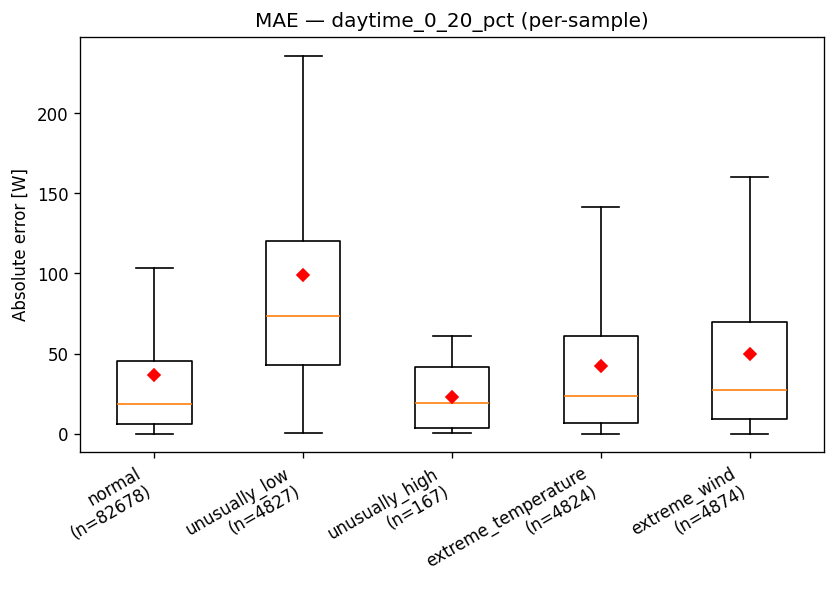

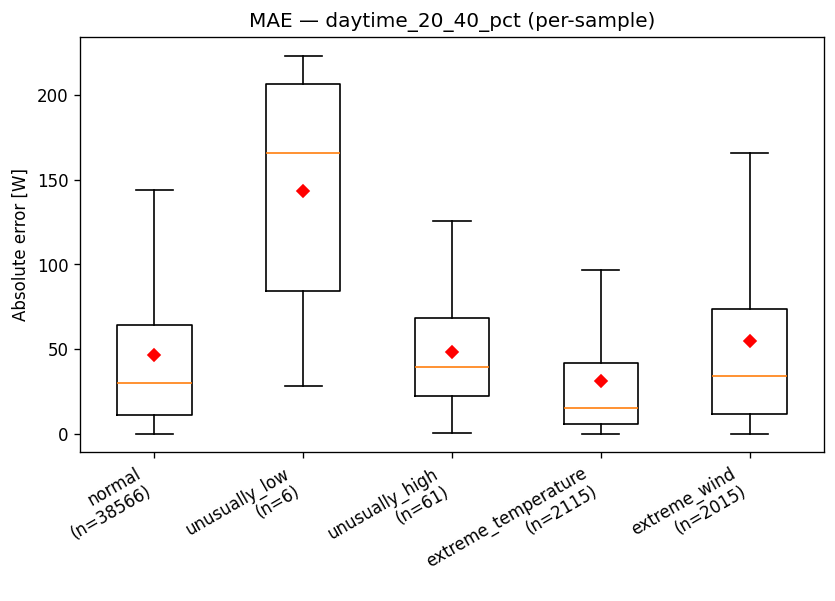

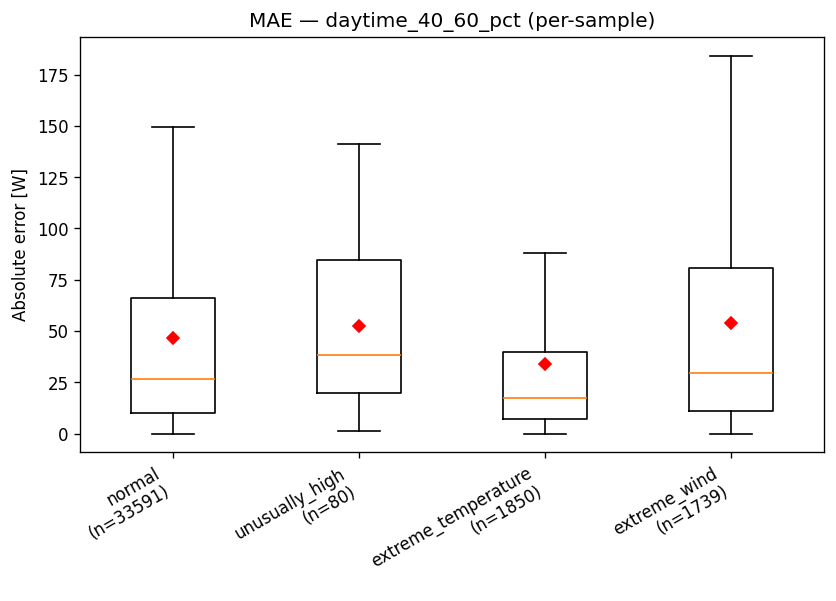

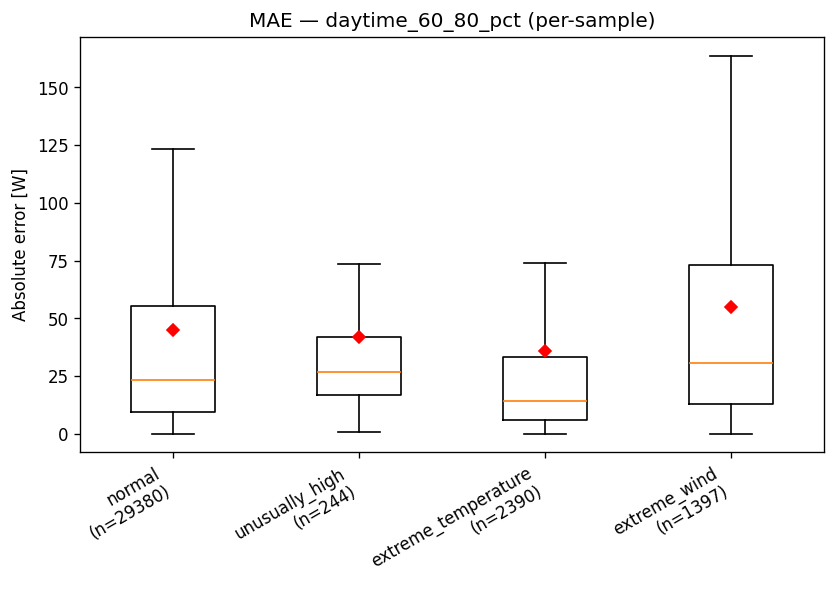

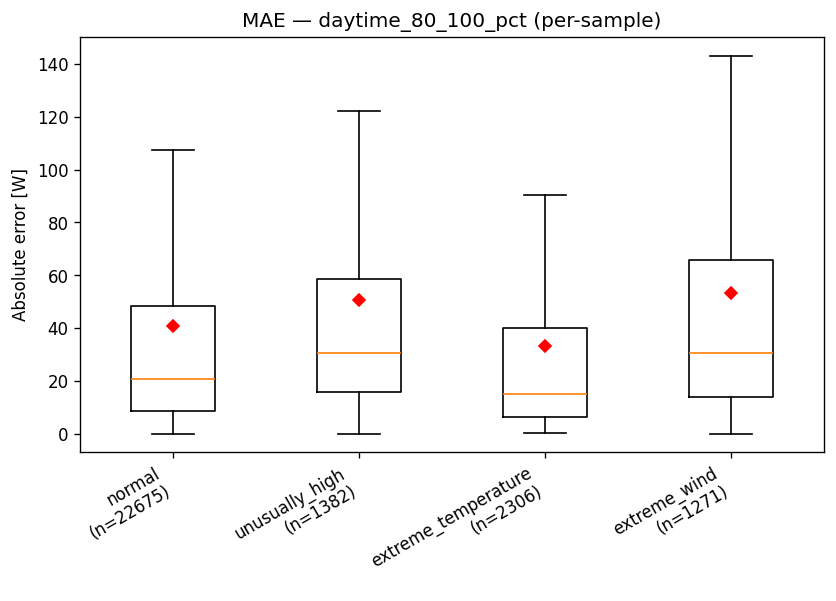

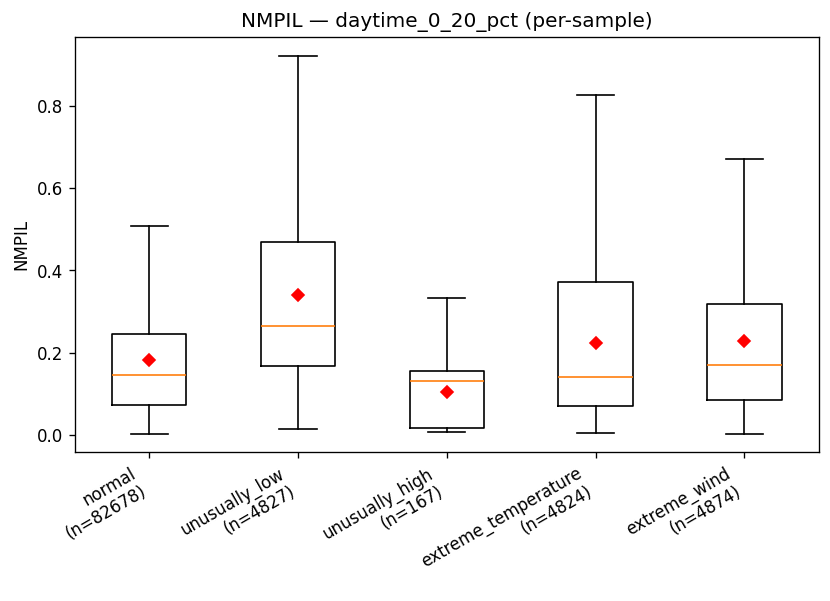

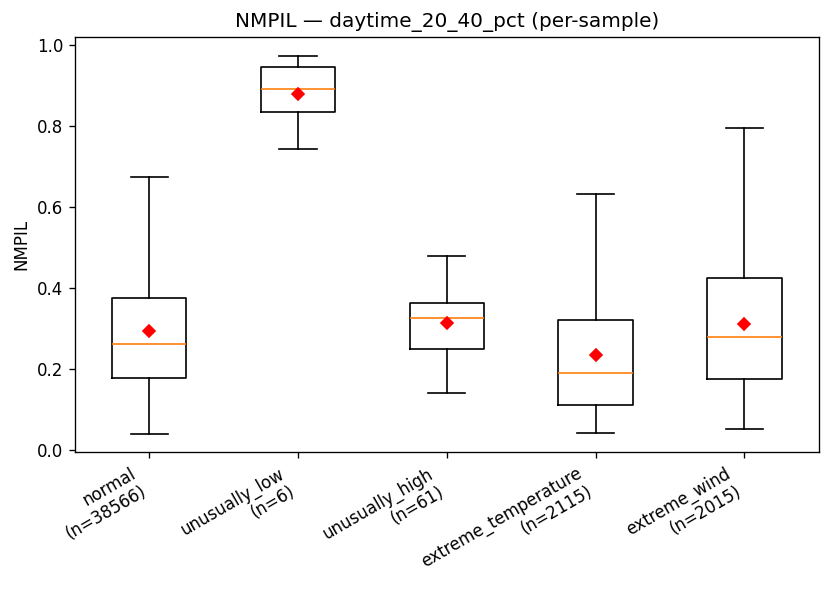

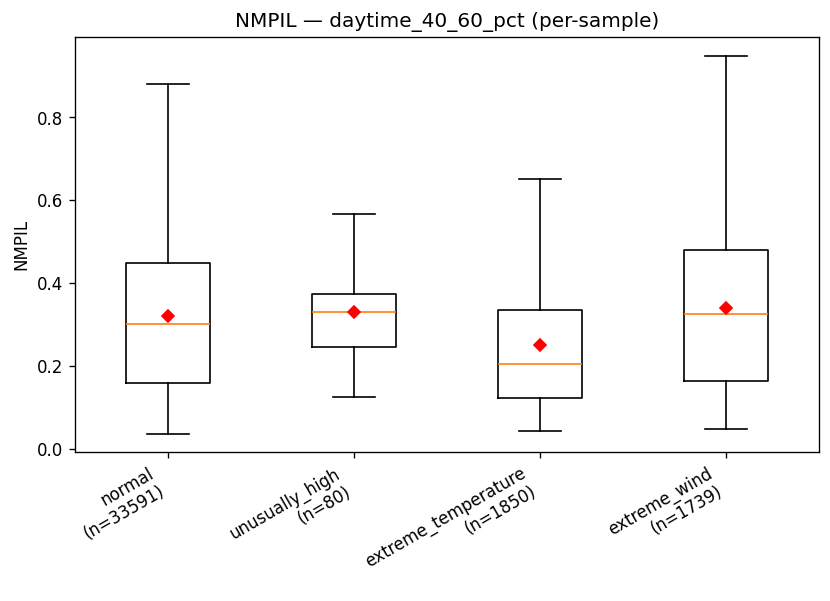

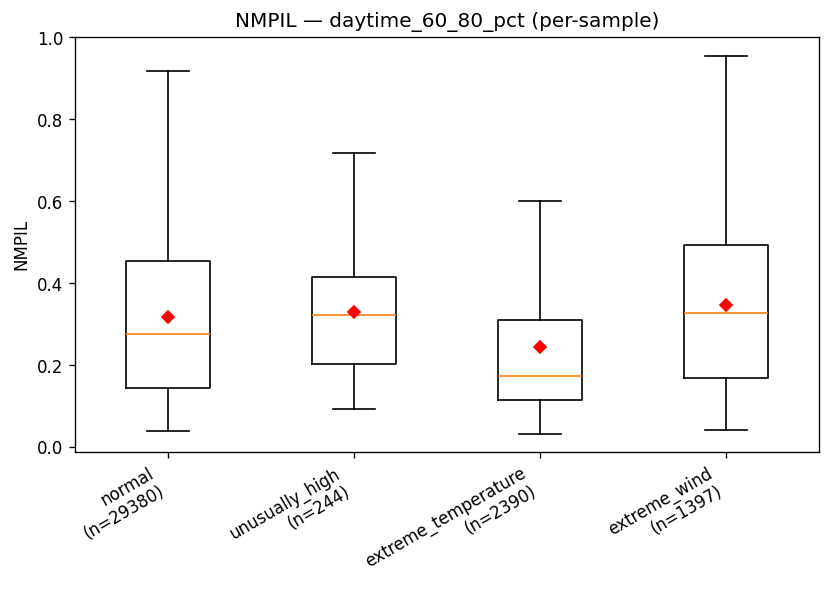

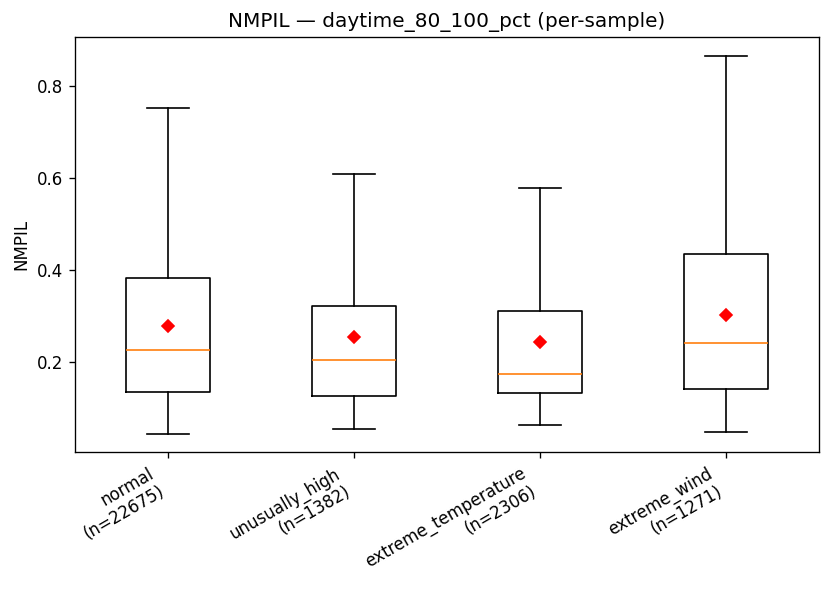

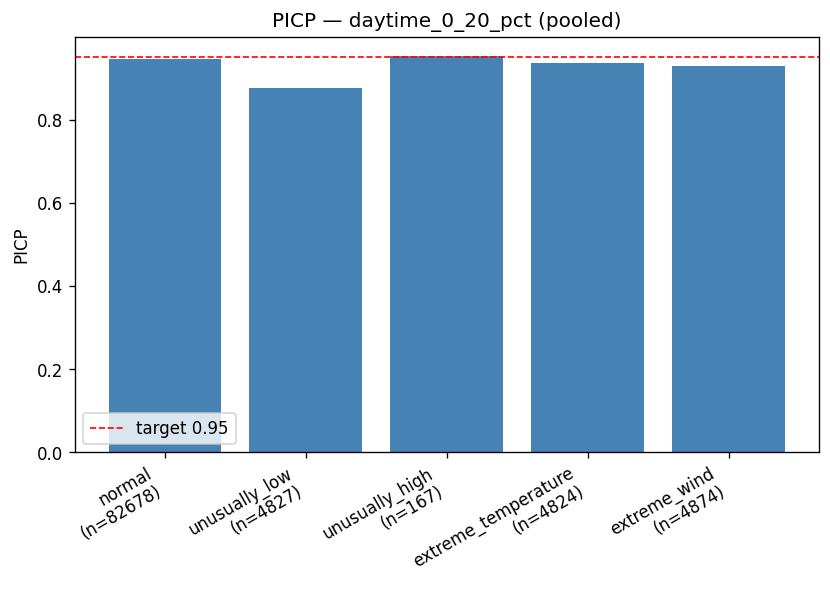

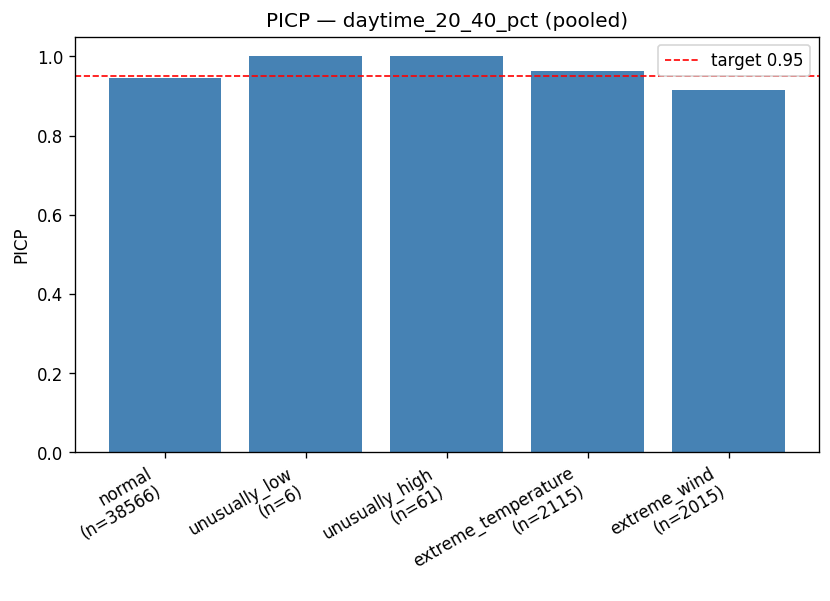

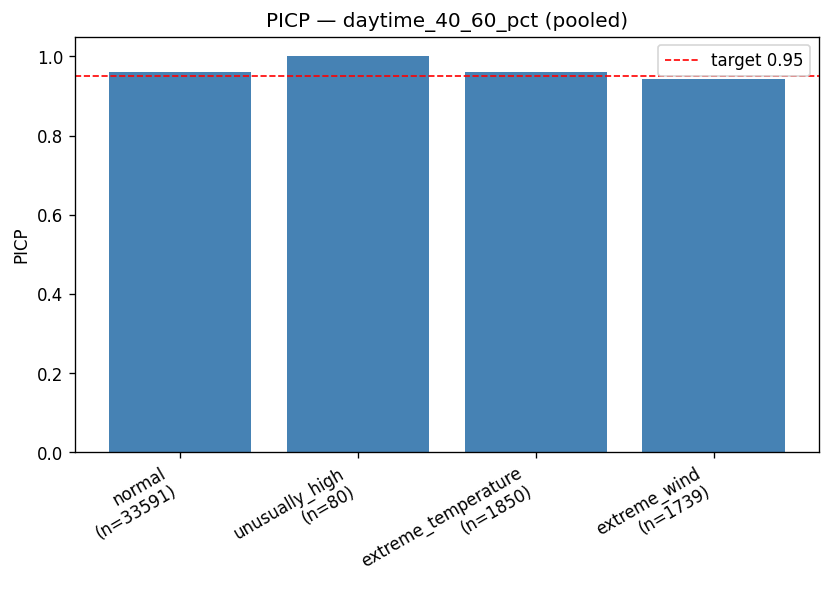

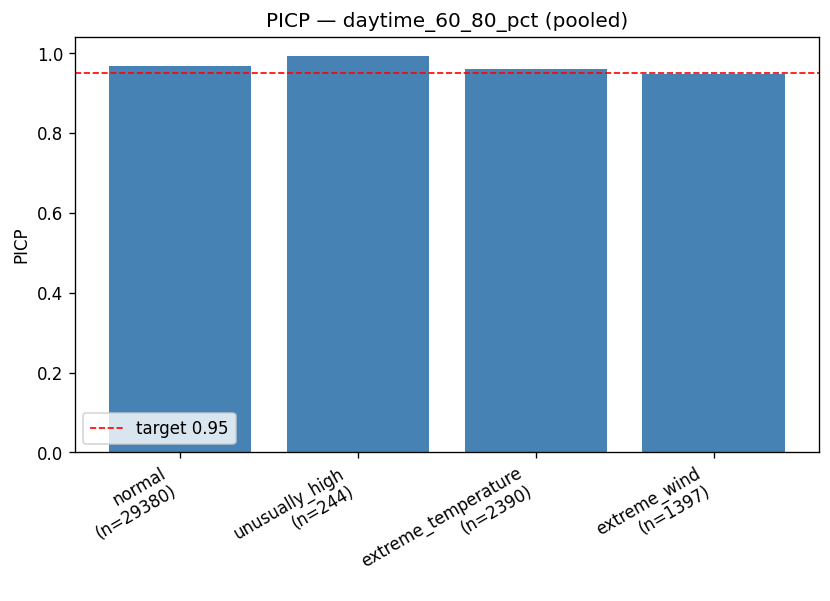

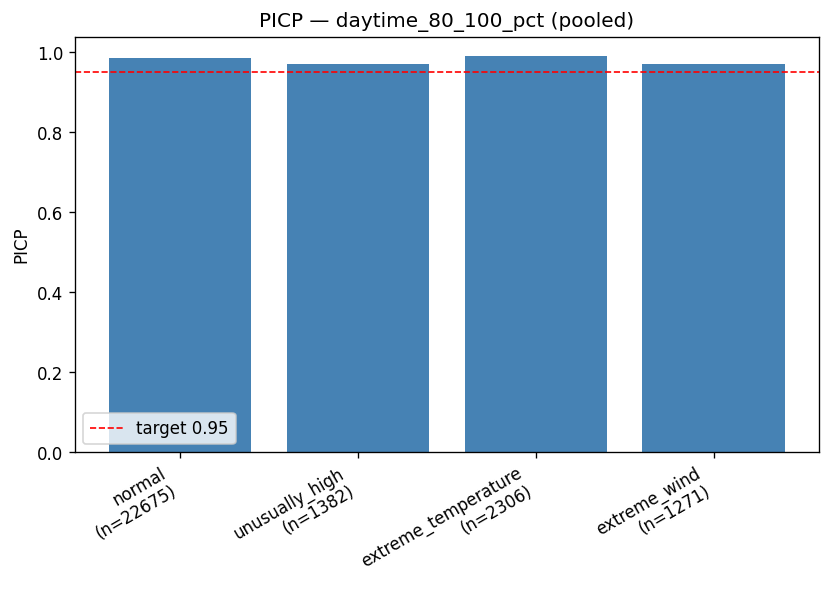

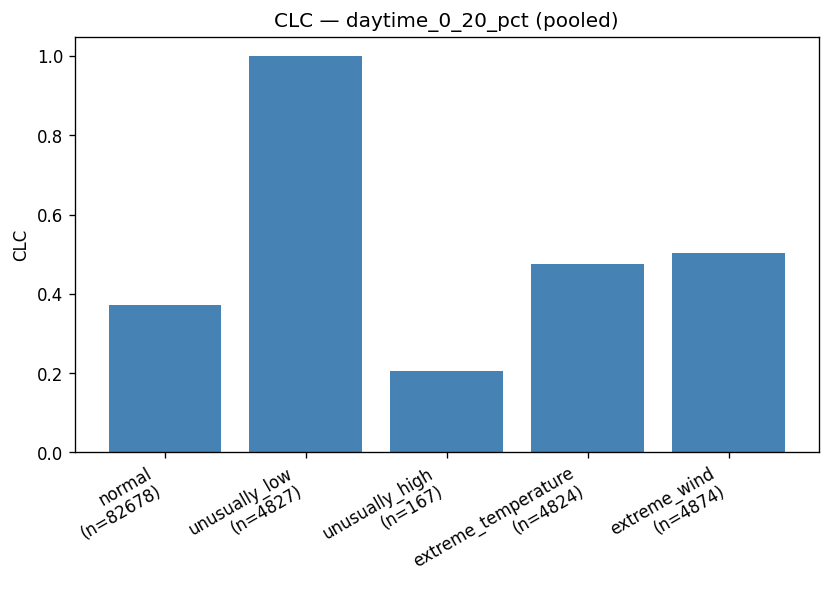

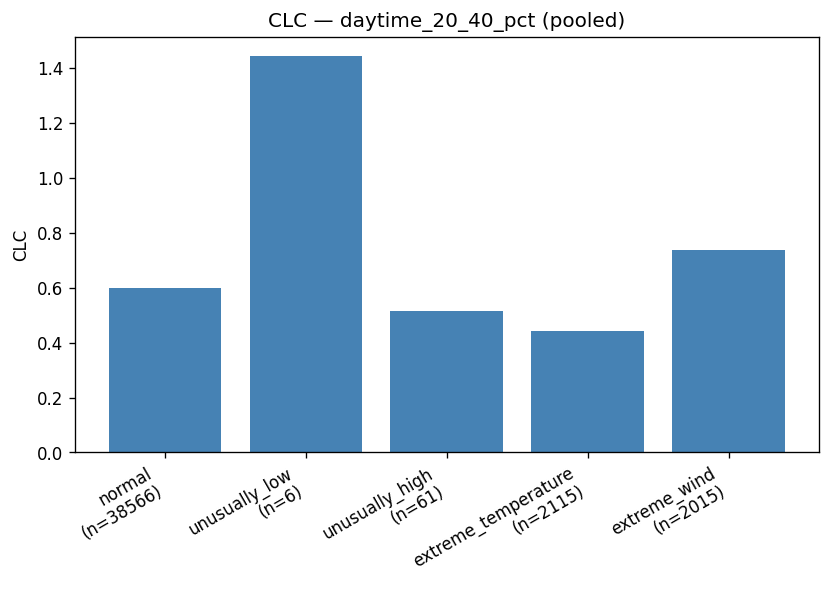

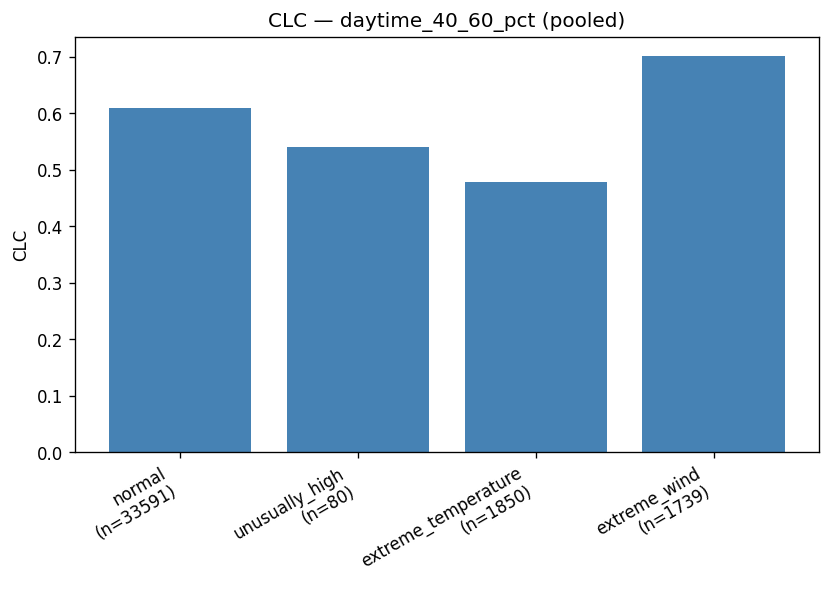

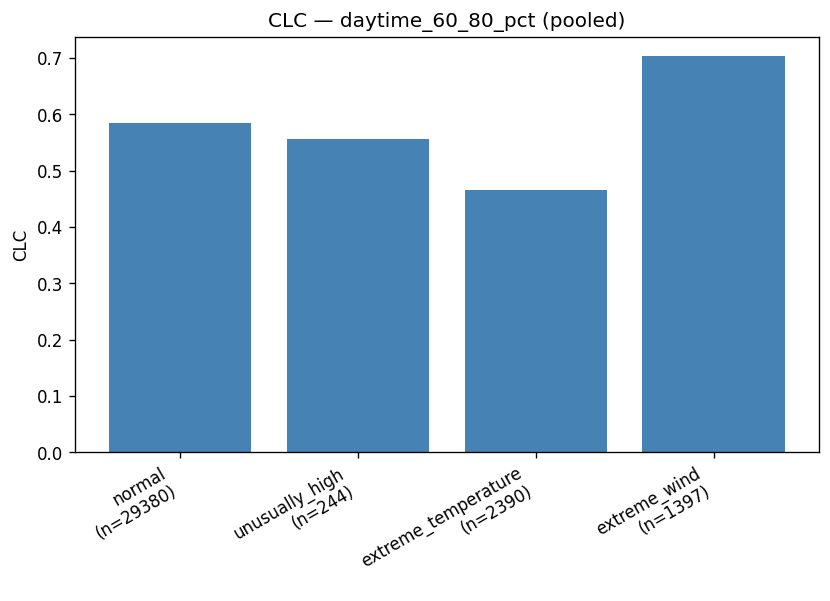

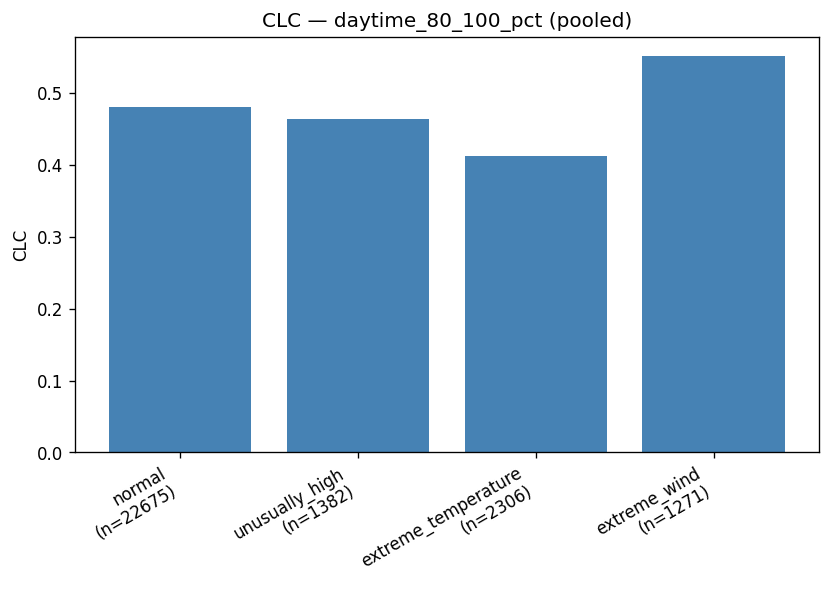

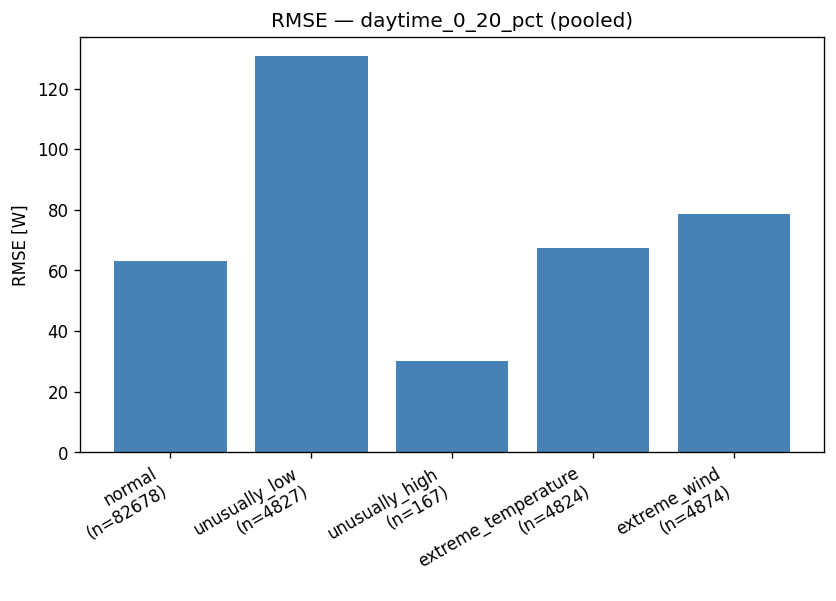

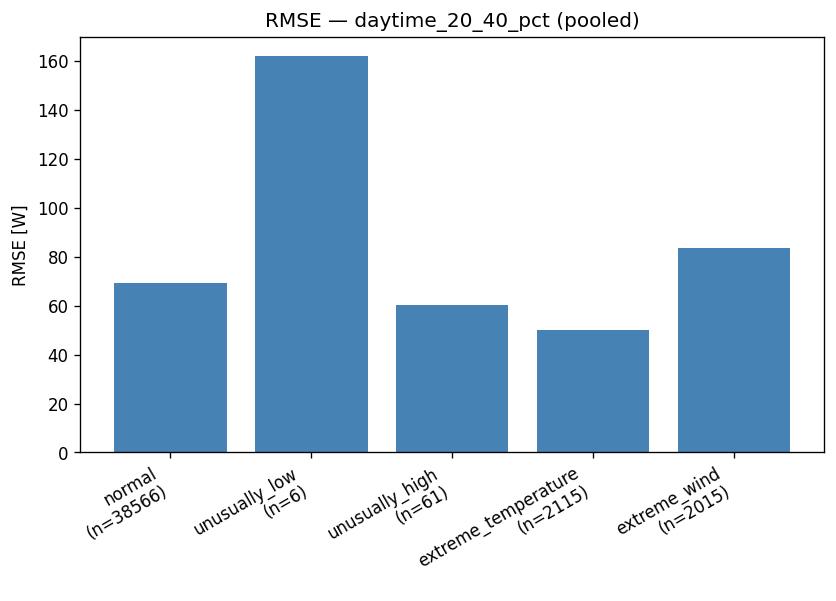

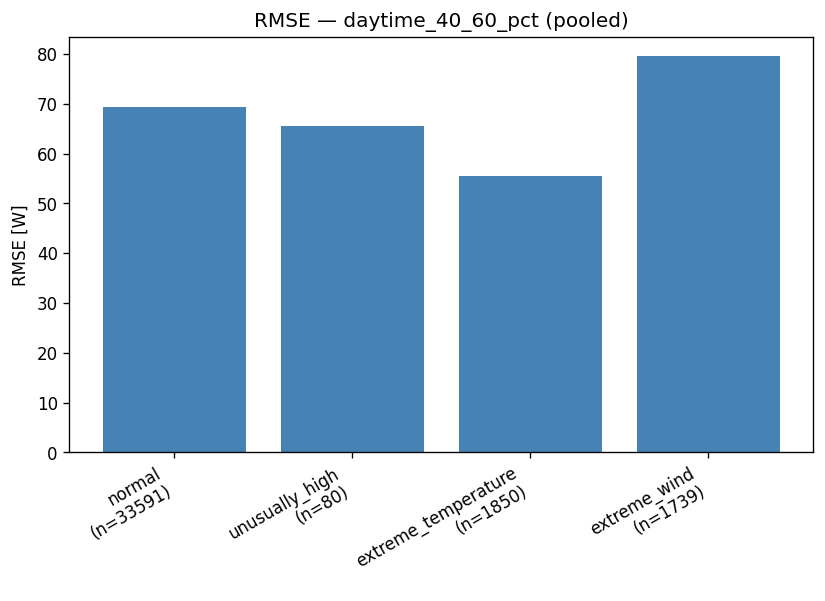

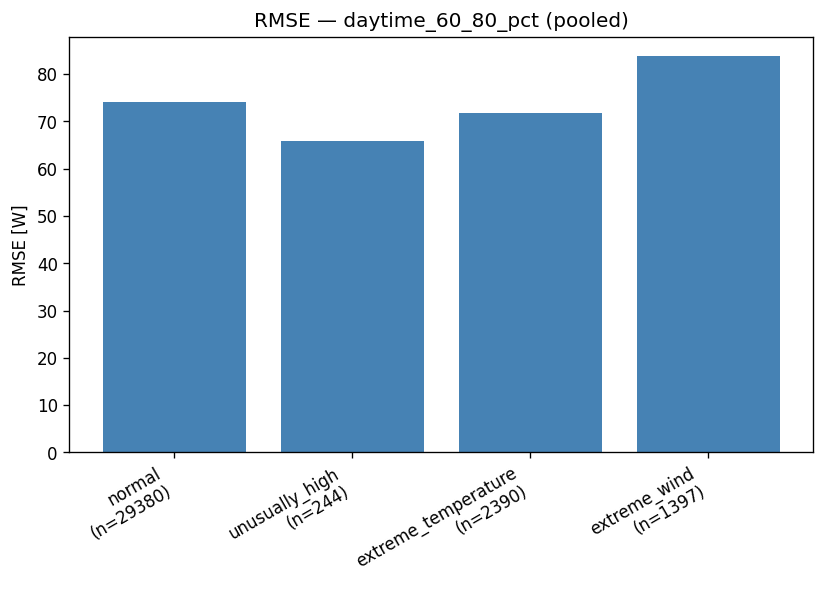

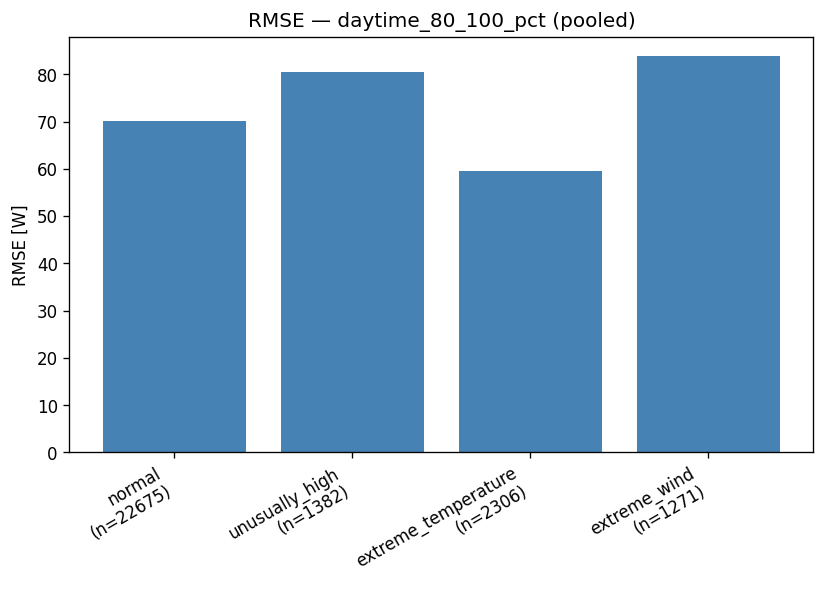

In [14]:
if figure_paths:
    from IPython.display import Image, display
    for path in figure_paths.values():
        display(Image(filename=str(path)))

## 7. W&B sweep (optional)

In [15]:
print('Sweep disabled: this notebook defines one controlled exploratory run.')

Sweep disabled: this notebook defines one controlled exploratory run.


In [16]:
# Intentionally no W&B sweep registration in the single-run notebook.

## 8. Log post-hoc results to W&B (optional)

Adds post-hoc scalars and figures to the matching W&B run without uploading artifacts.
The sweep wrapper does this automatically per run.

In [17]:
LOG_TO_WANDB = True
if LOG_TO_WANDB:
    import wandb
    run = pipe.init_wandb_run_for_out_dir(wandb, out_dir, run_name=run_name)
    try:
        posthoc = pipe.log_posthoc_to_wandb(
            wandb, run, out_dir,
            figure_paths=figure_paths if 'figure_paths' in dir() else None,
            upload_artifact=False,
        )
        print(posthoc['summary'])
        print('posthoc artifact upload disabled; uploaded:', posthoc['artifact_uploaded'])
    finally:
        run.finish()
else:
    print('LOG_TO_WANDB is False. posthoc summary preview:')
    if Path(out_dir, 'sharpness_overview.csv').exists():
        print(pipe.read_posthoc_summary(out_dir))

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/apedalino/.netrc.
wandb: Currently logged in as: albertopedalino (albertopedalino-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


{'posthoc/daytime_picp': 0.9531090279291718, 'posthoc/daytime_mpiw': 224.5615225943732, 'posthoc/daytime_nmpil': 0.2517900989709073, 'posthoc/normal_picp': 0.9553953113535488, 'posthoc/rare_extreme_picp': 0.9370199510745816, 'posthoc/unusually_low_picp': 0.8695530985784633, 'posthoc/high_production_picp': 0.9847680578228448, 'posthoc/gt100_picp': 0.9847680578228448}
posthoc artifact upload disabled; uploaded: False


posthoc/daytime_mpiw,▁
posthoc/daytime_nmpil,▁
posthoc/daytime_picp,▁
posthoc/gt100_picp,▁
posthoc/high_production_picp,▁
posthoc/normal_picp,▁
posthoc/rare_extreme_picp,▁
posthoc/unusually_low_picp,▁
best_epoch,59
best_validation_metric,rmse_daytime
best_validation_score,71.25406
